#### Libraries Import

In [46]:
#Libraries
# requirements.txt contain all libraries used in this project
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import shapiro, f_oneway, kruskal

In [32]:
#Dataset loading
df = pd.read_csv("candy-data.csv")

df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


#### Data Exploration

- dataset is concise, not extensive
- PCA seems great fit to get a general perspective about data
- dataset contains categorical values (0,1) and some continuous features
- Need to encode categorical values into something machine readable

In [33]:
#Selecting categorical columns
#Sugar and price are already percentage, so no need encoding.

cols_to_encode = [
    "chocolate",
    "fruity",
    "caramel",
    "peanutyalmondy",
    "nougat",
    "crispedricewafer",
    "hard",
    "bar",
    "pluribus"
]

enc_values = df[cols_to_encode]
freq_df = df.copy()

for col in enc_values:
    freq = enc_values[col].value_counts(normalize=True)
    freq_df[col] = freq_df[col].map(freq)

freq_df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,0.435294,0.552941,0.164706,0.835294,0.917647,0.082353,0.823529,0.247059,0.482353,0.732,0.860,66.971725
1,3 Musketeers,0.435294,0.552941,0.835294,0.835294,0.082353,0.917647,0.823529,0.247059,0.482353,0.604,0.511,67.602936
2,One dime,0.564706,0.552941,0.835294,0.835294,0.917647,0.917647,0.823529,0.752941,0.482353,0.011,0.116,32.261086
3,One quarter,0.564706,0.552941,0.835294,0.835294,0.917647,0.917647,0.823529,0.752941,0.482353,0.011,0.511,46.116505
4,Air Heads,0.564706,0.447059,0.835294,0.835294,0.917647,0.917647,0.823529,0.752941,0.482353,0.906,0.511,52.341465


##### PCA data exploration

In [34]:
class PCAFunc:
    def __init__(self, scaler=None, num_comp=2, flip_pca1=False, flip_pca2=False):
        self.scaler = scaler if scaler is not None else StandardScaler()
        self.num_comp = num_comp
        self.flip_pca1 = flip_pca1
        self.flip_pca2 = flip_pca2

        self.pca_model = None
        self.pca_df = None
        self.explained_variance_ratio_ = None
        self.input_cols = None

    def pca(self, input_df, input_cols, include_sugar_price=False):
        self.input_cols = input_cols.copy()

        if include_sugar_price:
            self.input_cols = list(
                dict.fromkeys(input_cols + ["sugarpercent", "pricepercent"])
            )

        X = input_df[self.input_cols]

        X_scaled = self.scaler.fit_transform(X)

        self.pca_model = PCA(n_components=self.num_comp)
        pca_values = self.pca_model.fit_transform(X_scaled)

        self.pca_df = pd.DataFrame(
            pca_values,
            columns=[f"PCA{i+1}" for i in range(self.num_comp)],
            index=input_df.index
        )

        if self.flip_pca1:
            self.pca_df["PCA1"] = -self.pca_df["PCA1"]

        if self.flip_pca2:
            self.pca_df["PCA2"] = -self.pca_df["PCA2"]

        for col in ["competitorname", "sugarpercent", "pricepercent", "winpercent"]:
            if col in input_df.columns:
                self.pca_df[col] = input_df[col]

        self.explained_variance_ratio_ = self.pca_model.explained_variance_ratio_

        return self.pca_df, self.explained_variance_ratio_

    def pca_plot(self, use_winpercent_size=False, show_loadings=False, arrow_scale=3):
        pca_df = self.pca_df.copy()

        pca_df["sugar_group"] = pd.qcut(
            pca_df["sugarpercent"],
            q=3,
            labels=["Low sugar", "Medium sugar", "High sugar"]
        )

        shape_map = {
            "Low sugar": "o",
            "Medium sugar": "s",
            "High sugar": "^"
        }

        if use_winpercent_size:
            pca_df["marker_size"] = 50 + (
                (pca_df["winpercent"] - pca_df["winpercent"].min()) /
                (pca_df["winpercent"].max() - pca_df["winpercent"].min())
            ) * 250
        else:
            pca_df["marker_size"] = 90

        plt.figure(figsize=(12, 8))

        for sugar_group, marker in shape_map.items():
            subset = pca_df[pca_df["sugar_group"] == sugar_group]

            scatter = plt.scatter(
                subset["PCA1"],
                subset["PCA2"],
                c=subset["pricepercent"],
                cmap="viridis",
                marker=marker,
                s=subset["marker_size"],
                edgecolor="black",
                alpha=0.85,
                label=sugar_group
            )

        plt.colorbar(scatter, label="Price Percent")

        if show_loadings:
            loadings = self.pca_model.components_.T.copy()

            if self.flip_pca1:
                loadings[:, 0] = -loadings[:, 0]

            if self.flip_pca2:
                loadings[:, 1] = -loadings[:, 1]

            for i, feature in enumerate(self.input_cols):
                plt.arrow(
                    0,
                    0,
                    loadings[i, 0] * arrow_scale,
                    loadings[i, 1] * arrow_scale,
                    color="red",
                    alpha=0.8,
                    head_width=0.08,
                    length_includes_head=True
                )

                plt.text(
                    loadings[i, 0] * arrow_scale * 1.15,
                    loadings[i, 1] * arrow_scale * 1.15,
                    feature,
                    color="red",
                    fontsize=10
                )

            plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
            plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

        plt.xlabel(f"PCA 1 ({self.explained_variance_ratio_[0]:.1%} variance)")
        plt.ylabel(f"PCA 2 ({self.explained_variance_ratio_[1]:.1%} variance)")

        title = "PCA of Candy Features"

        if use_winpercent_size:
            title += "\nMarker size = Win Percent"

        if show_loadings:
            title += " with Loadings"

        plt.title(title)

        plt.legend(title="Sugar Percent Group")
        plt.show()

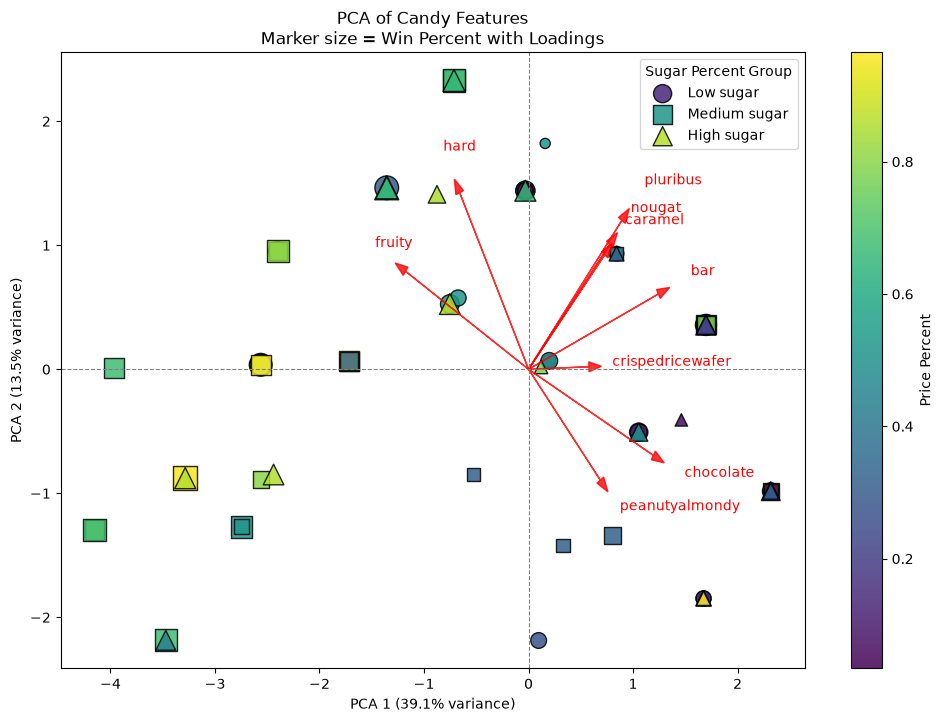

In [35]:
#First PCA without sugar and price
pca_runner = PCAFunc(num_comp=2)

pca_df, explained_variance = pca_runner.pca(
    input_df=freq_df,
    input_cols=cols_to_encode,
    include_sugar_price=False
)

pca_runner.pca_plot(
    use_winpercent_size=True,
    show_loadings=True,
    arrow_scale=3
)

##### PCA including sugar and price

- Since most attributes are categorical, even encoding them as frequencies, most data have similar values thus creating overlap
- Including sugar and price in PCA, which are continuous values spreads the data, creating better visualization

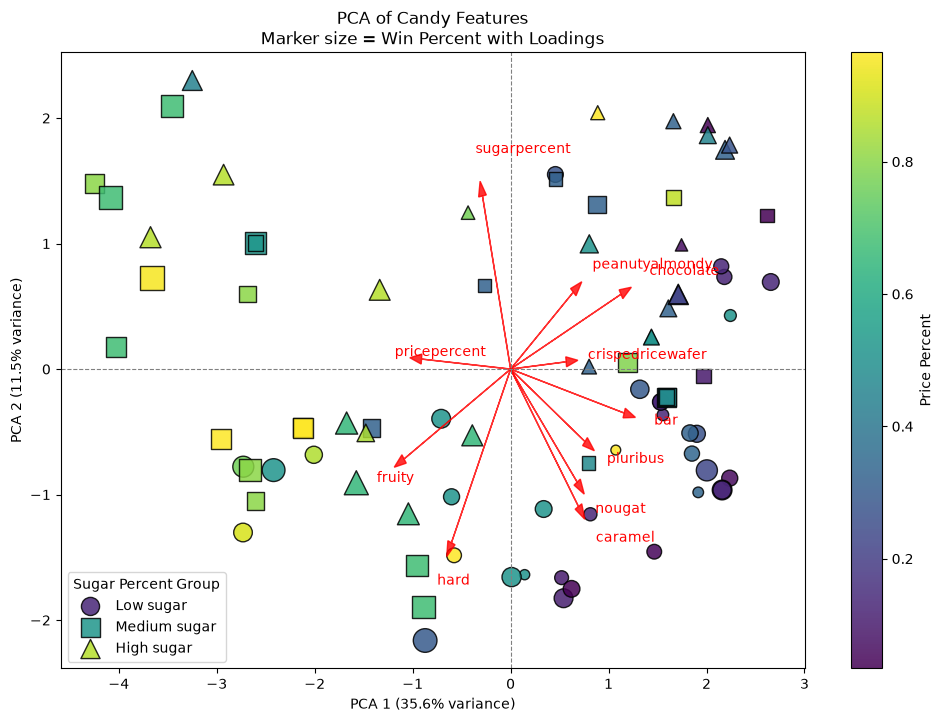

In [36]:
#PCA execution including sugar and price
pca_runner = PCAFunc(num_comp=2)

pca_df, explained_variance = pca_runner.pca(
    input_df=freq_df,
    input_cols=cols_to_encode,
    include_sugar_price=True
)

pca_runner.pca_plot(
    use_winpercent_size=True,
    show_loadings=True,
    arrow_scale=3
)

##### Using Kmeans in order to cluster data

In [37]:
class KMeansCluster:
    def __init__(self, n_clusters=3, random_state=42, n_init=10):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init

        self.kmeans_model = None
        self.cluster_df = None

    def fit(self, pca_df):
        self.cluster_df = pca_df.copy()

        self.kmeans_model = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=self.n_init
        )

        self.cluster_df["cluster"] = self.kmeans_model.fit_predict(
            self.cluster_df[["PCA1", "PCA2"]]
        )

        return self.cluster_df

    def plot(
        self,
        pca_model=None,
        input_cols=None,
        explained_variance_ratio=None,
        show_loadings=False,
        arrow_scale=3,
        use_sugar_shapes=False,
        use_winpercent_size=False
    ):
        if self.cluster_df is None:
            raise ValueError("Run .fit(pca_df) before plotting.")

        if show_loadings and (pca_model is None or input_cols is None):
            raise ValueError("To show loadings, provide pca_model and input_cols.")

        plot_df = self.cluster_df.copy()

        cluster_colors = {
            0: "red",
            1: "blue",
            2: "green",
            3: "orange",
            4: "purple",
            5: "brown",
            6: "pink",
            7: "gray"
        }

        if use_sugar_shapes:
            plot_df["sugar_group"] = pd.qcut(
                plot_df["sugarpercent"],
                q=3,
                labels=["Low sugar", "Medium sugar", "High sugar"]
            )

            shape_map = {
                "Low sugar": "o",
                "Medium sugar": "s",
                "High sugar": "^"
            }
        else:
            plot_df["sugar_group"] = "All"
            shape_map = {"All": "o"}

        if use_winpercent_size:
            win_min = plot_df["winpercent"].min()
            win_max = plot_df["winpercent"].max()

            plot_df["marker_size"] = 50 + (
                (plot_df["winpercent"] - win_min) /
                (win_max - win_min)
            ) * 250
        else:
            plot_df["marker_size"] = 100

        plt.figure(figsize=(12, 8))

        for cluster_id in sorted(plot_df["cluster"].unique()):
            for sugar_group, marker in shape_map.items():
                subset = plot_df[
                    (plot_df["cluster"] == cluster_id) &
                    (plot_df["sugar_group"] == sugar_group)
                ]

                if subset.empty:
                    continue

                plt.scatter(
                    subset["PCA1"],
                    subset["PCA2"],
                    color=cluster_colors.get(cluster_id, "black"),
                    marker=marker,
                    s=subset["marker_size"],
                    edgecolor="black",
                    alpha=0.85
                )

        if show_loadings:
            loadings = pca_model.components_.T.copy()

            for i, feature in enumerate(input_cols):
                plt.arrow(
                    0,
                    0,
                    loadings[i, 0] * arrow_scale,
                    loadings[i, 1] * arrow_scale,
                    color="black",
                    alpha=0.8,
                    head_width=0.08,
                    length_includes_head=True
                )

                plt.text(
                    loadings[i, 0] * arrow_scale * 1.15,
                    loadings[i, 1] * arrow_scale * 1.15,
                    feature,
                    color="black",
                    fontsize=10
                )

            plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
            plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")

        if explained_variance_ratio is not None:
            plt.xlabel(f"PCA 1 ({explained_variance_ratio[0]:.1%} variance)")
            plt.ylabel(f"PCA 2 ({explained_variance_ratio[1]:.1%} variance)")
        else:
            plt.xlabel("PCA 1")
            plt.ylabel("PCA 2")

        title = "KMeans Clustering on PCA Values"

        if show_loadings:
            title += " with PCA Loadings"

        plt.title(title)

        cluster_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                color="white",
                label=f"Cluster {cluster_id}",
                markerfacecolor=cluster_colors.get(cluster_id, "black"),
                markeredgecolor="black",
                markersize=10
            )
            for cluster_id in sorted(plot_df["cluster"].unique())
        ]

        handles = cluster_handles

        if use_sugar_shapes:
            sugar_handles = [
                Line2D(
                    [0],
                    [0],
                    marker=marker,
                    color="white",
                    label=sugar_group,
                    markerfacecolor="gray",
                    markeredgecolor="black",
                    markersize=10
                )
                for sugar_group, marker in shape_map.items()
            ]

            handles = cluster_handles + sugar_handles

        plt.legend(
            handles=handles,
            title="Cluster / Sugar Shape",
            bbox_to_anchor=(1.05, 1),
            loc="upper left"
        )

        plt.show()

- Using Silhouete score in order to determine the optimal number of clusters

k=3, silhouette score=0.4481
k=4, silhouette score=0.4423
k=5, silhouette score=0.4478
k=6, silhouette score=0.4738
k=7, silhouette score=0.4461


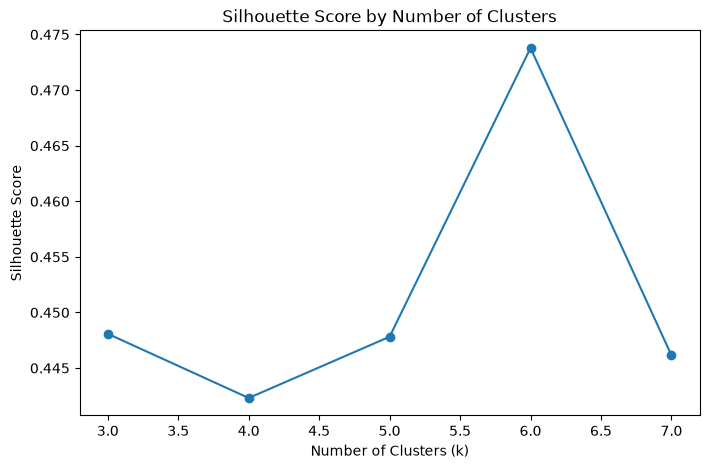

In [38]:
#Using silhouette score to decide the optimal number of clusters

scores = []
k_values = range(3, 8)

for k in k_values:
    kmeans_runner = KMeansCluster(n_clusters=k)
    cluster_df = kmeans_runner.fit(pca_df)

    score = silhouette_score(
        pca_df[["PCA1", "PCA2"]],
        cluster_df["cluster"]
    )

    scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

- Plotting of the 6 clusters, with PCA loadings

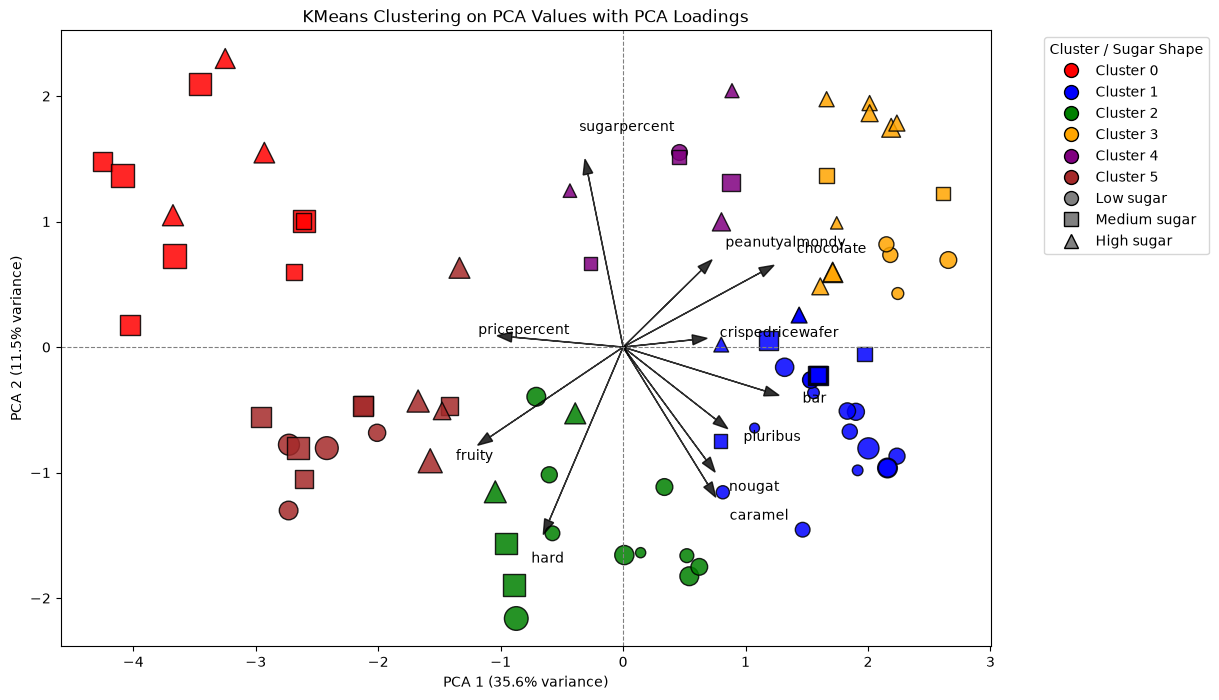

In [39]:
kmeans_runner = KMeansCluster(n_clusters=6)

cluster_df = kmeans_runner.fit(pca_df)

kmeans_runner.plot(
    pca_model=pca_runner.pca_model,
    input_cols=pca_runner.input_cols,
    explained_variance_ratio=pca_runner.explained_variance_ratio_,
    show_loadings=True,
    use_sugar_shapes=True,
    use_winpercent_size=True
)

- Investigating the attributes variation for each cluster
- Cluster 0 appears to be the most successful cluster
- Cluser 0 also displays the hight sugar percent among clusters and it is 2nd in price percent
- The 3 bottom tier clusters on win percent display lower prices vs the top 3 tier clusters

In [86]:
cluster_df[["competitorname", "PCA1", "PCA2", "cluster"]].sort_values("cluster")

cluster_summary = (
    cluster_df
    .join(df[cols_to_encode])
    .groupby("cluster")[cols_to_encode + ["sugarpercent", "pricepercent", "winpercent"]]
    .mean()
)

cluster_summary.sort_values(by="winpercent", ascending=False)

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
cluster,,,,,,,,,,,,
0,0.909091,0.000000,0.727273,0.363636,0.636364,0.272727,0.000000,1.000000,0.000000,0.636909,0.688727,62.987308
5,1.000000,0.000000,0.071429,0.357143,0.000000,0.285714,0.000000,0.714286,0.142857,0.536857,0.762786,61.903705
2,0.857143,0.000000,0.071429,0.357143,0.000000,0.000000,0.000000,0.000000,0.785714,0.329071,0.471357,54.388043
3,0.000000,0.933333,0.000000,0.000000,0.000000,0.000000,0.800000,0.000000,0.733333,0.616533,0.266133,43.070504
1,0.000000,0.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.791667,0.328875,0.313500,42.967379
4,0.142857,0.571429,0.571429,0.000000,0.000000,0.000000,0.428571,0.000000,0.142857,0.630714,0.497857,39.815058


- Investigating the initial attributes for each cluster

In [110]:
# Add cluster labels from PCA/KMeans back to the original dataframe
df_clustered = df.copy()
df_clustered["cluster"] = cluster_df["cluster"]

# Columns to inspect per candy
inspect_cols = (
    ["cluster", "competitorname", "winpercent", "sugarpercent", "pricepercent"]
    + cols_to_encode
)

cluster_samples = df_clustered[inspect_cols].sort_values(
    ["cluster", "winpercent"],
    ascending=[True, False]
)

cluster_samples[cluster_samples["cluster"] == 1]

,cluster,competitorname,winpercent,sugarpercent,pricepercent,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus
68,1,Starburst,67.037628,0.151,0.220,0,1,0,0,0,0,0,0,1
66,1,Sour Patch Kids,59.863998,0.069,0.116,0,1,0,0,0,0,0,0,1
18,1,Haribo Gold Bears,57.119740,0.465,0.465,0,1,0,0,0,0,0,0,1
73,1,Swedish Fish,54.861111,0.604,0.755,0,1,0,0,0,0,0,0,1
31,1,Lifesavers big ring gummies,52.911392,0.267,0.279,0,1,0,0,0,0,0,0,0
67,1,Sour Patch Tricksters,52.825947,0.069,0.116,0,1,0,0,0,0,0,0,1
20,1,Haribo Sour Bears,51.412430,0.465,0.465,0,1,0,0,0,0,0,0,1
78,1,Trolli Sour Bites,47.173229,0.313,0.255,0,1,0,0,0,0,0,0,1
80,1,Twizzlers,45.466282,0.220,0.116,0,1,0,0,0,0,0,0,0
82,1,Welch's Fruit Snacks,44.375519,0.313,0.313,0,1,0,0,0,0,0,0,1


In [109]:
for cluster in cluster_samples['cluster'].unique():
    print(cluster)
    sum_cluster = int(cluster_samples[cluster_samples['cluster']==cluster].shape[0])
    mean_winpercent = cluster_samples[cluster_samples['cluster']==cluster]['winpercent'].mean()
    sd_mean = cluster_samples[cluster_samples['cluster']==cluster]['winpercent'].agg(
          mean_win="mean",
          sd_win="std"
      )
    win_index = sd_mean["sd_win"] / sd_mean["mean_win"]
    market_index = sum_cluster * (100 - mean_winpercent) * win_index
    print(sd_mean["sd_win"], sd_mean["mean_win"])
    print(f"Cluster: {cluster}, market_index: {market_index}")

0
12.59143056326998 62.987307818181826
Cluster: 0, market_index: 81.38893940403882
1
11.125213694782762 42.967378833333335
Cluster: 1, market_index: 354.40845512904684
2
16.836032546226267 54.38804342857143
Cluster: 2, market_index: 197.67104526917186
3
9.513871929199738 43.070504199999995
Cluster: 3, market_index: 188.627905139005
4
8.083344304300086 39.81505800000001
Cluster: 4, market_index: 85.53219379568192
5
11.358461199581214 61.90370492857142
Cluster: 5, market_index: 97.86189790777136


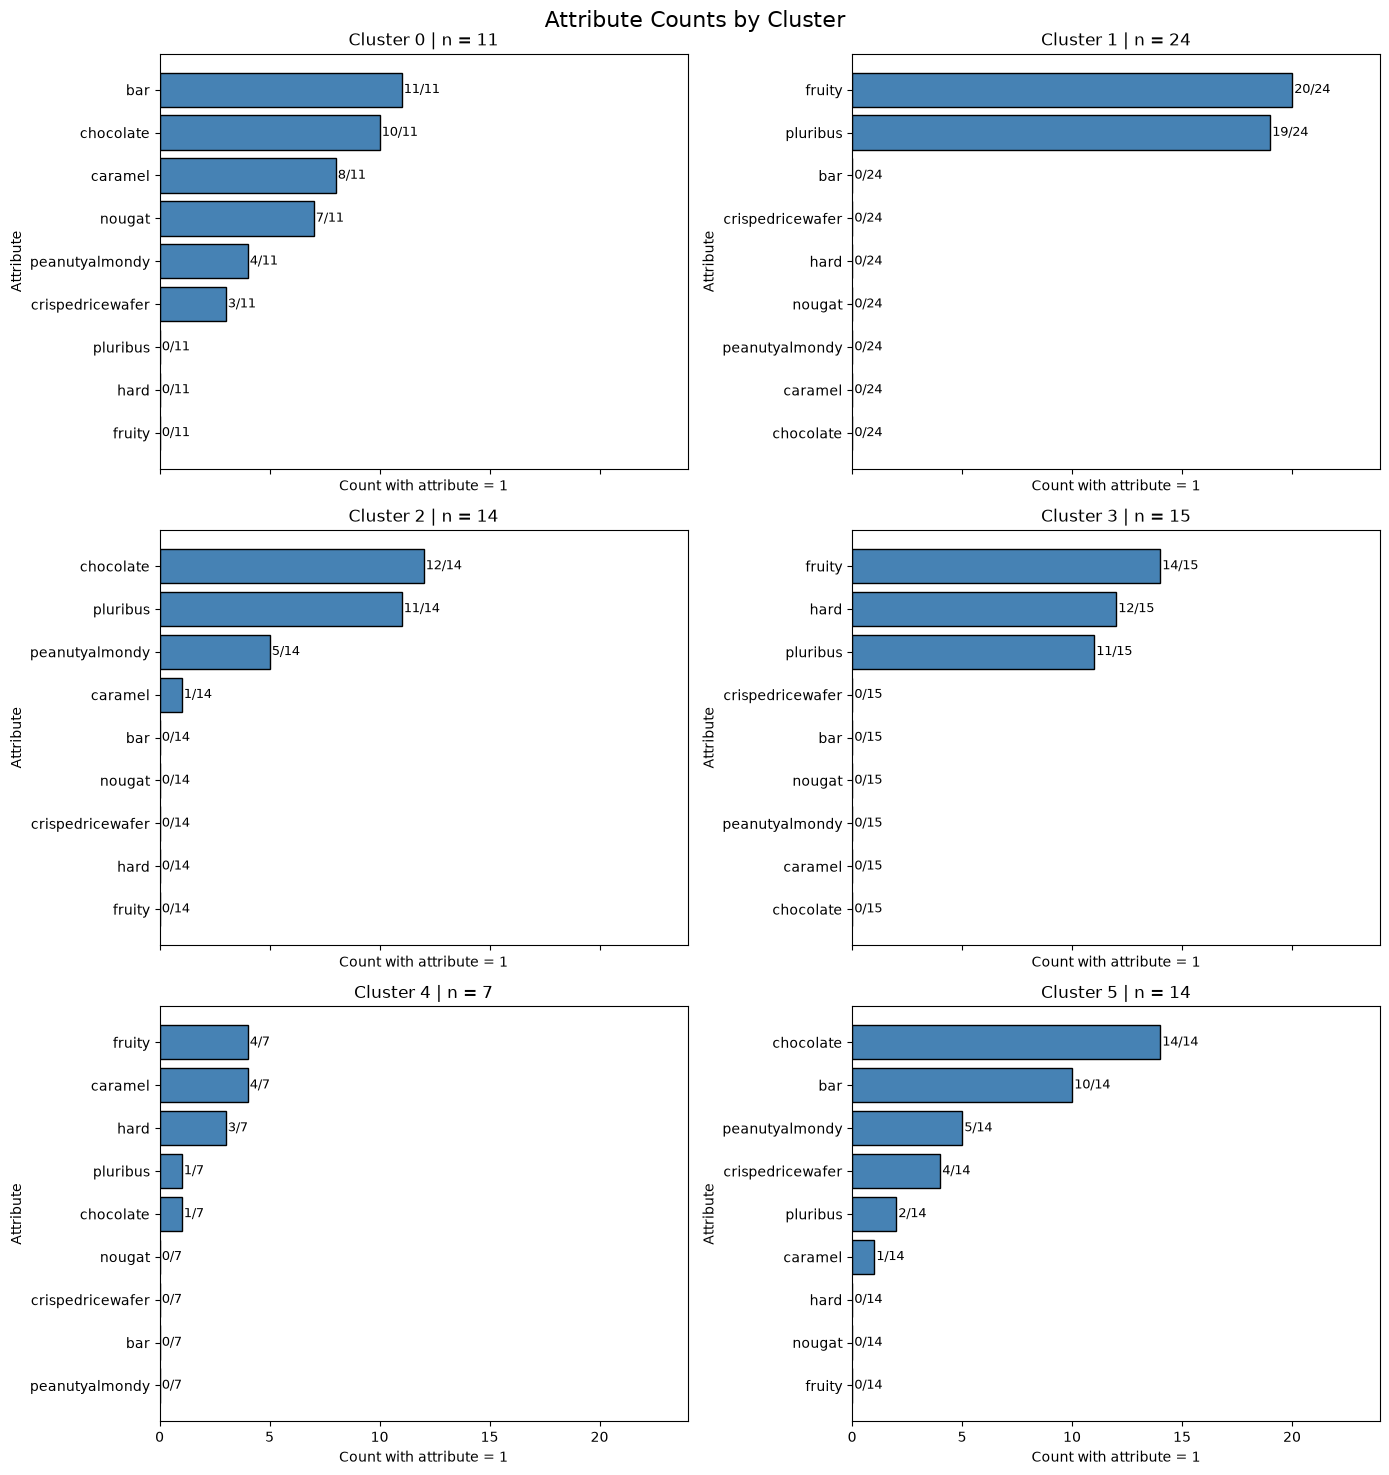

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Safely attach cluster labels
df_clustered = df.merge(
    cluster_df[["competitorname", "cluster"]],
    on="competitorname",
    how="inner"
)

cluster_sizes = (
    df_clustered
    .groupby("cluster")
    .size()
    .rename("cluster_size")
)

binary_counts_1 = (
    df_clustered
    .groupby("cluster")[cols_to_encode]
    .sum()
)

cluster_ids = sorted(df_clustered["cluster"].unique())

n_clusters = len(cluster_ids)
n_cols = 2
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 5 * n_rows),
    sharex=True
)

axes = np.array(axes).reshape(-1)

max_cluster_size = cluster_sizes.max()

for ax, cluster_id in zip(axes, cluster_ids):
    cluster_size = cluster_sizes.loc[cluster_id]
    attribute_counts = binary_counts_1.loc[cluster_id].sort_values(ascending=True)

    ax.barh(
        attribute_counts.index,
        attribute_counts.values,
        color="steelblue",
        edgecolor="black"
    )

    ax.set_xlim(0, max_cluster_size)
    ax.set_title(f"Cluster {cluster_id} | n = {cluster_size}")
    ax.set_xlabel("Count with attribute = 1")
    ax.set_ylabel("Attribute")

    for i, value in enumerate(attribute_counts.values):
        ax.text(
            value + 0.1,
            i,
            f"{int(value)}/{cluster_size}",
            va="center",
            fontsize=9
        )

# Hide empty subplots if cluster count is odd
for ax in axes[len(cluster_ids):]:
    ax.axis("off")

fig.suptitle("Attribute Counts by Cluster", fontsize=16)
plt.tight_layout()
plt.show()

In [69]:
normality_results = []

for cluster_id in sorted(cluster_df["cluster"].unique()):
    values = cluster_df.loc[
        cluster_df["cluster"] == cluster_id,
        "winpercent"
    ]

    stat, p_value = shapiro(values)

    normality_results.append({
        "cluster": cluster_id,
        "n": len(values),
        "shapiro_stat": stat,
        "p_value": p_value,
        "normal_distribution": p_value > 0.05
    })

normality_df = pd.DataFrame(normality_results)

normality_df

,cluster,n,shapiro_stat,p_value,normal_distribution
0,0,11,0.969737,0.883866,True
1,1,24,0.985838,0.975130,True
2,2,14,0.975416,0.939481,True
3,3,15,0.955303,0.611435,True
4,4,7,0.852717,0.130119,True
5,5,14,0.941658,0.439987,True


In [70]:
groups = [
    cluster_df.loc[cluster_df["cluster"] == cluster_id, "winpercent"]
    for cluster_id in sorted(cluster_df["cluster"].unique())
]

if normality_df["normal_distribution"].all():
    stat, p_value = f_oneway(*groups)
    test_used = "One-way ANOVA"
else:
    stat, p_value = kruskal(*groups)
    test_used = "Kruskal-Wallis"

print(f"Test used: {test_used}")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

Test used: One-way ANOVA
Statistic: 9.2889
p-value: 0.0000


In [71]:
from scipy.stats import mannwhitneyu
from itertools import combinations

pairwise_results = []

for c1, c2 in combinations(sorted(cluster_df["cluster"].unique()), 2):
    group1 = cluster_df.loc[cluster_df["cluster"] == c1, "winpercent"]
    group2 = cluster_df.loc[cluster_df["cluster"] == c2, "winpercent"]

    stat, p_value = mannwhitneyu(group1, group2, alternative="two-sided")

    pairwise_results.append({
        "cluster_1": c1,
        "cluster_2": c2,
        "p_value": p_value
    })

pairwise_df = pd.DataFrame(pairwise_results)

# Bonferroni correction
pairwise_df["p_value_bonferroni"] = (
    pairwise_df["p_value"] * len(pairwise_df)
).clip(upper=1)

pairwise_df["significant"] = pairwise_df["p_value_bonferroni"] <= 0.05

pairwise_df

,cluster_1,cluster_2,p_value,p_value_bonferroni,significant
0,0,1,0.000355,0.005332,True
1,0,2,0.179839,1.000000,False
2,0,3,0.001292,0.019377,True
3,0,4,0.001194,0.017911,True
4,0,5,0.681376,1.000000,False
5,1,2,0.026134,0.392014,False
6,1,3,0.919522,1.000000,False
7,1,4,0.340747,1.000000,False
8,1,5,0.000114,0.001712,True
9,2,3,0.057631,0.864462,False


In [72]:
from scipy.stats import chi2_contingency, kruskal
import pandas as pd

binary_cols = [
    "chocolate",
    "fruity",
    "caramel",
    "peanutyalmondy",
    "nougat",
    "crispedricewafer",
    "hard",
    "bar",
    "pluribus"
]

continuous_cols = ["sugarpercent", "pricepercent"]

chi_square_results = []

for col in binary_cols:
    contingency_table = pd.crosstab(
        df_clustered["cluster"],
        df_clustered[col]
    )

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    chi_square_results.append({
        "attribute": col,
        "test": "Chi-square",
        "chi2_stat": chi2,
        "p_value": p_value,
        "significant": p_value <= 0.05
    })

chi_square_df = pd.DataFrame(chi_square_results)
chi_square_df.sort_values("p_value")

,attribute,test,chi2_stat,p_value,significant
0,chocolate,Chi-square,70.840792,6.848886e-14,True
7,bar,Chi-square,69.640731,1.217284e-13,True
1,fruity,Chi-square,60.804938,8.286067e-12,True
6,hard,Chi-square,56.689796,5.858912e-11,True
4,nougat,Chi-square,51.317016,7.447242e-10,True
2,caramel,Chi-square,43.181884,3.394322e-08,True
8,pluribus,Chi-square,37.660077,4.415448e-07,True
3,peanutyalmondy,Chi-square,19.771290,1.379430e-03,True
5,crispedricewafer,Chi-square,18.321440,2.569392e-03,True
